# End-to-End ML Pipeline for Sales/Price Data

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [17]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2638 entries, 2019-01-01 to 2018-08-01
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Estimated_Deliveries              2638 non-null   int64  
 1   Production_Units                  2638 non-null   int64  
 2   Avg_Price_USD                     2638 non-null   float64
 3   Battery_Capacity_kWh              2638 non-null   int64  
 4   Range_km                          2638 non-null   int64  
 5   CO2_Saved_tons                    2638 non-null   float64
 6   Charging_Stations                 2638 non-null   int64  
 7   Year                              2638 non-null   int32  
 8   Quarter                           2638 non-null   int32  
 9   Month                             2638 non-null   int32  
 10  DayOfWeek                         2638 non-null   int32  
 11  Deliveries_Price_Interaction      2638 non-null   f

## 1. Preprocessing

In [5]:
# Combine 'Year' and 'Month' into a 'Date' column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Set the 'Date' column as the DataFrame index
df.set_index('Date', inplace=True)

# Drop the original 'Year' and 'Month' columns
df.drop(['Year', 'Month'], axis=1, inplace=True)

# Display the first 5 rows of the DataFrame with the new index
display(df.head())

# Display basic information about the DataFrame after preprocessing
df.info()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,
2023-05-01,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
2015-02-01,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2019-01-01,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
2021-02-01,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
2016-12-01,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2640 entries, 2023-05-01 to 2018-08-01
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Region                2640 non-null   object 
 1   Model                 2640 non-null   object 
 2   Estimated_Deliveries  2640 non-null   int64  
 3   Production_Units      2640 non-null   int64  
 4   Avg_Price_USD         2640 non-null   float64
 5   Battery_Capacity_kWh  2640 non-null   int64  
 6   Range_km              2640 non-null   int64  
 7   CO2_Saved_tons        2640 non-null   float64
 8   Source_Type           2640 non-null   object 
 9   Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 226.9+ KB


## 2. Exploratory Data Analysis (EDA)

In [6]:
# Check for and remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
removed_rows = initial_rows - df.shape[0]

if removed_rows > 0:
    print(f"Removed {removed_rows} duplicate rows.")
else:
    print("No duplicate rows found.")

# Display descriptive statistics for numerical columns
display(df.describe())

No duplicate rows found.


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### Visualizing Distributions of Numerical Features

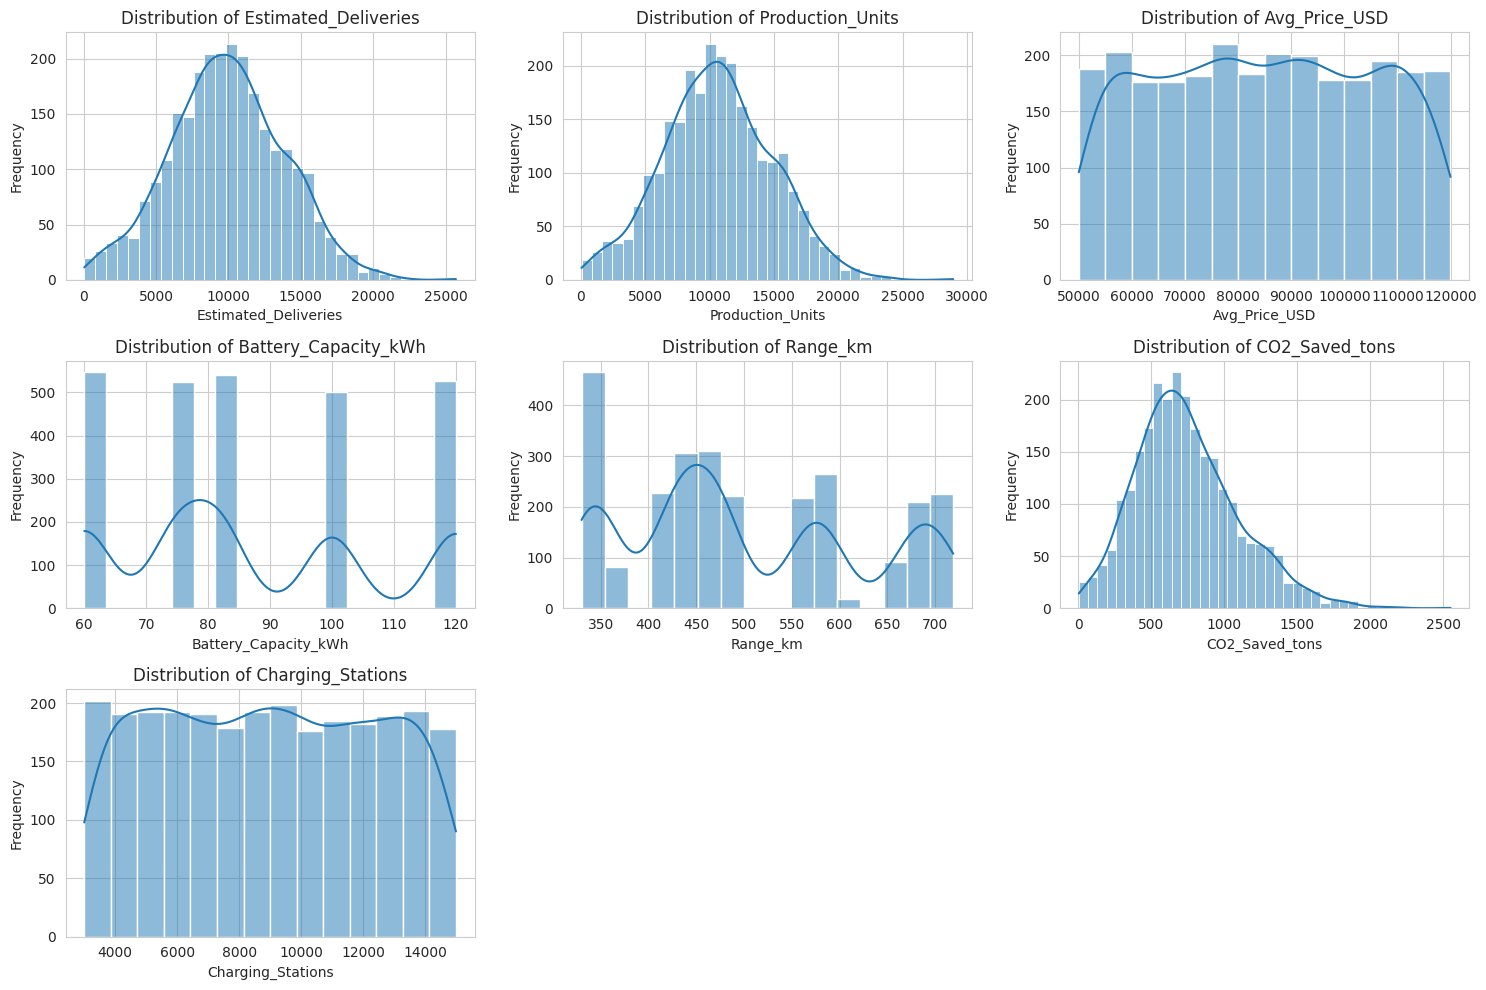


Unique values for categorical columns:
Column 'Region': 4 unique values - ['Europe' 'Asia' 'North America' 'Middle East']
Column 'Model': 5 unique values - ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Column 'Source_Type': 3 unique values - ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Identify numerical columns for distribution plots
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot distributions of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nUnique values for categorical columns:")
for col in categorical_cols:
    print(f"Column '{col}': {df[col].nunique()} unique values - {df[col].unique()}")

### Time Series Analysis of Key Metrics

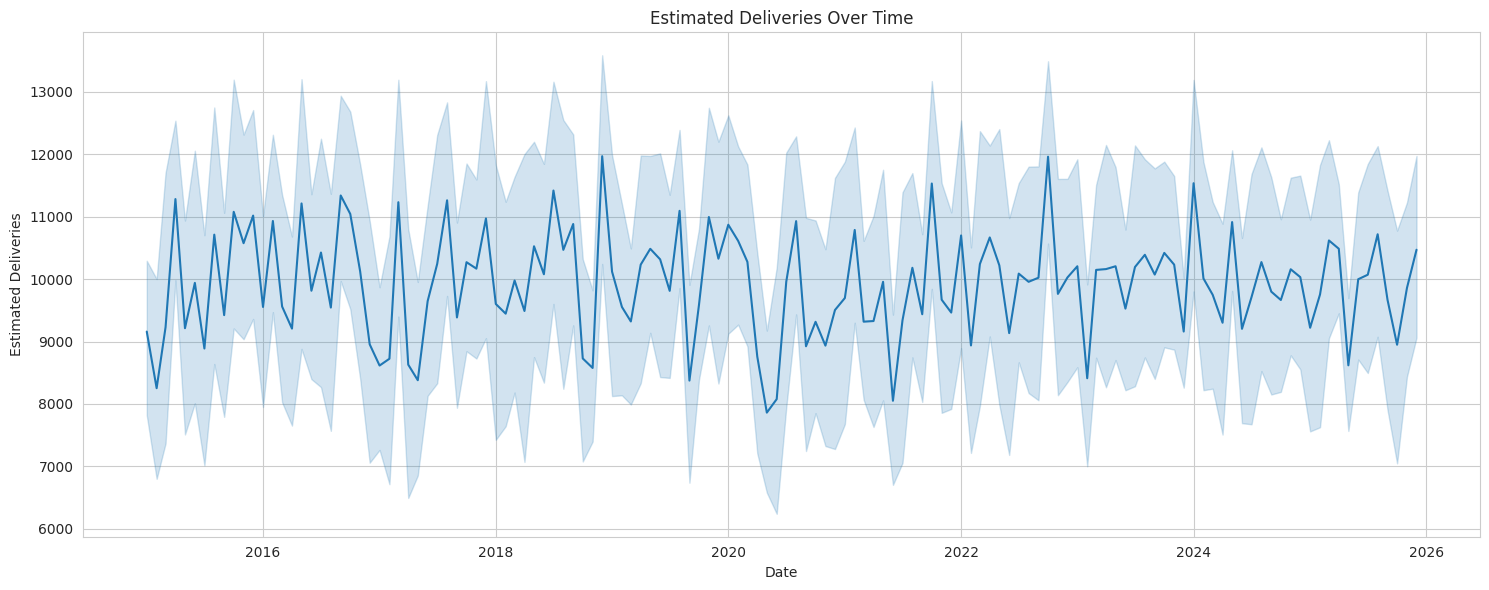

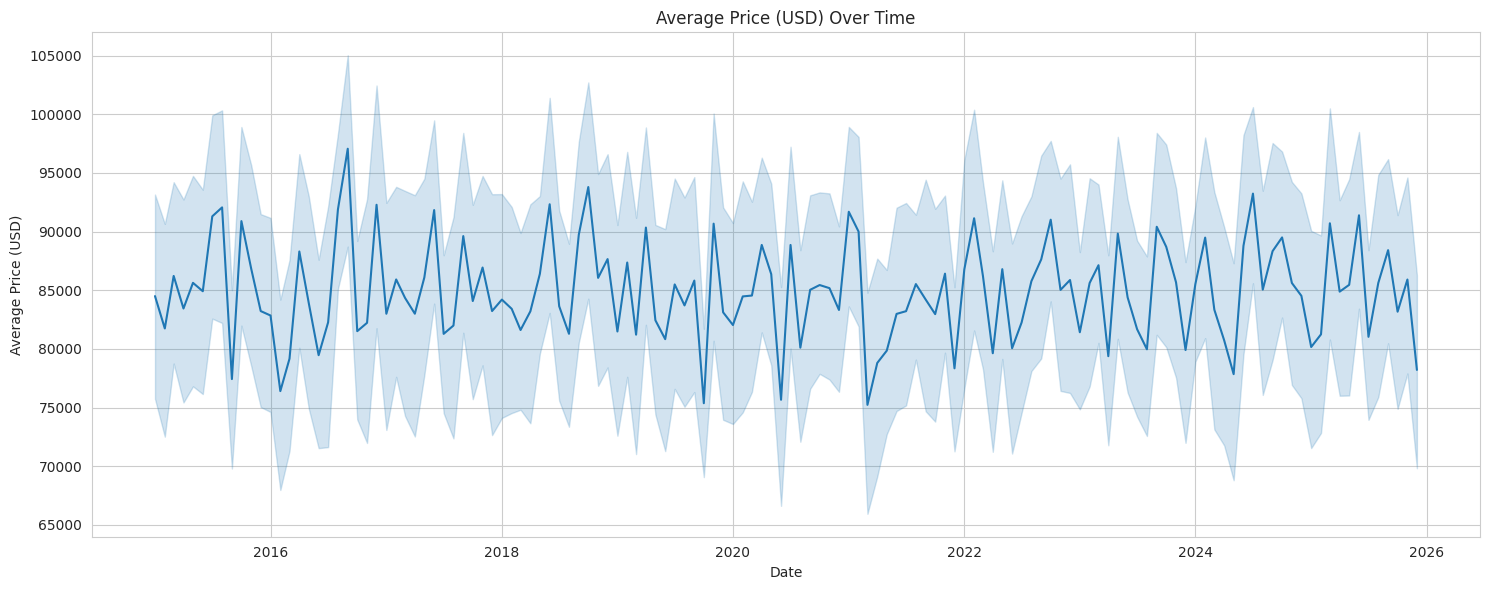

In [8]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x=df.index, y='Estimated_Deliveries')
plt.title('Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x=df.index, y='Avg_Price_USD')
plt.title('Average Price (USD) Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.tight_layout()
plt.show()

### Correlation Analysis

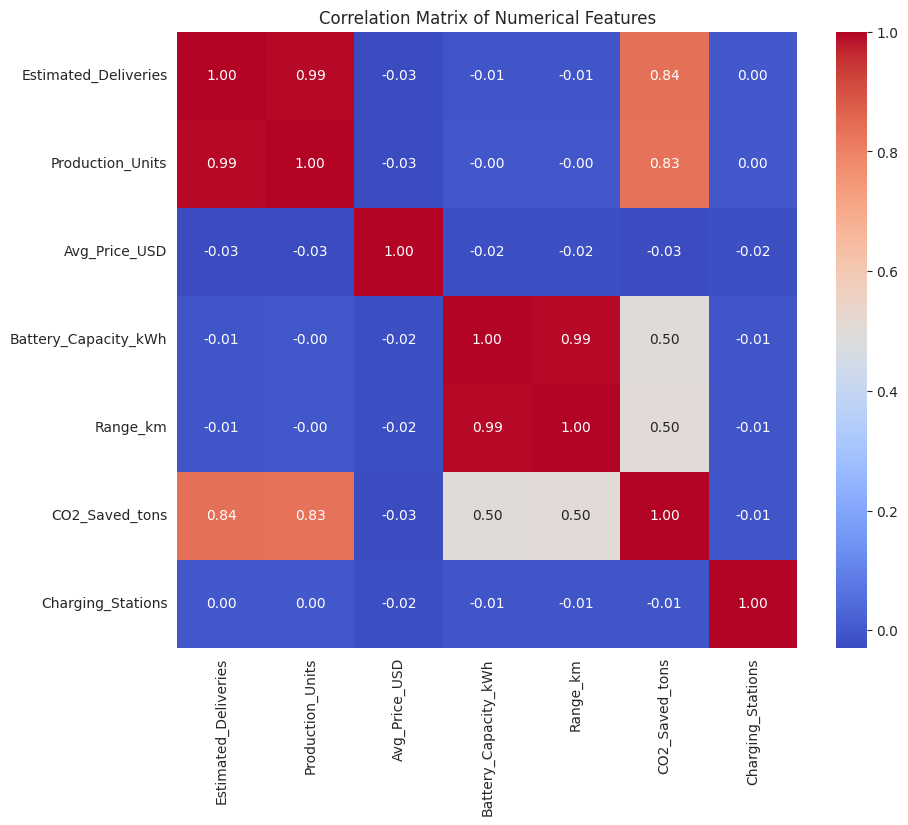

In [9]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Impact of Categorical Features on Estimated Deliveries

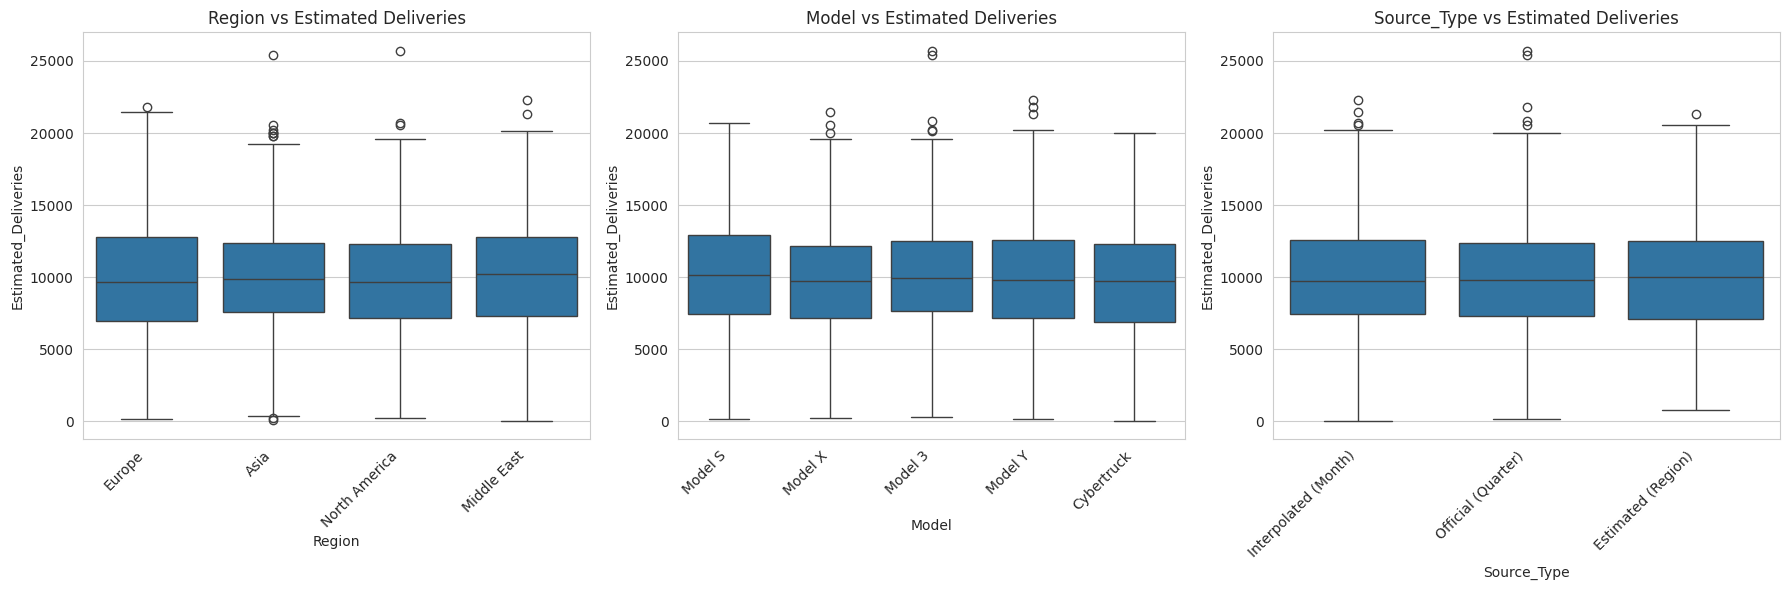

In [10]:
plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, len(categorical_cols), i)
    sns.boxplot(x=col, y='Estimated_Deliveries', data=df)
    plt.title(f'{col} vs Estimated Deliveries')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [11]:
# Extract time-based features from the Date index
df['Year'] = df.index.year
df['Quarter'] = df.index.quarter
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek # Monday=0, Sunday=6

# Display the first few rows with the new features
display(df.head())

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Year,Quarter,Month,DayOfWeek
Date,,,,,,,,,,,,,,
2023-05-01,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023,2,5,0
2015-02-01,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015,1,2,6
2019-01-01,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019,1,1,1
2021-02-01,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021,1,2,0
2016-12-01,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016,4,12,3


In [12]:
# Create interaction features
df['Deliveries_Price_Interaction'] = df['Estimated_Deliveries'] * df['Avg_Price_USD']

# Create lag features for Estimated_Deliveries
df['Estimated_Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Estimated_Deliveries_Lag2'] = df['Estimated_Deliveries'].shift(2)

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

# Drop rows with NaN values resulting from lag features
df.dropna(inplace=True)

# Display the first few rows with the new features
display(df.head())

# Display basic information about the DataFrame after feature engineering
df.info()

,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Year,Quarter,Month,...,Estimated_Deliveries_Lag2,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,8411,9189,117887.32,82,480,605.59,14071,2019,1,1,...,17646.0,False,False,True,False,False,True,False,True,False
2021-02-01,6555,7311,89294.91,120,712,700.07,9333,2021,1,2,...,3797.0,False,False,True,True,False,False,False,False,True
2016-12-01,12374,13537,114846.78,120,661,1226.88,8722,2016,4,12,...,8411.0,False,True,False,False,False,False,True,False,False
2020-04-01,4656,5043,86930.57,82,477,333.14,5798,2020,2,4,...,6555.0,False,False,False,False,False,True,False,False,True
2015-11-01,7717,7976,87588.21,82,475,549.84,9961,2015,4,11,...,12374.0,False,False,False,True,False,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2638 entries, 2019-01-01 to 2018-08-01
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Estimated_Deliveries              2638 non-null   int64  
 1   Production_Units                  2638 non-null   int64  
 2   Avg_Price_USD                     2638 non-null   float64
 3   Battery_Capacity_kWh              2638 non-null   int64  
 4   Range_km                          2638 non-null   int64  
 5   CO2_Saved_tons                    2638 non-null   float64
 6   Charging_Stations                 2638 non-null   int64  
 7   Year                              2638 non-null   int32  
 8   Quarter                           2638 non-null   int32  
 9   Month                             2638 non-null   int32  
 10  DayOfWeek                         2638 non-null   int32  
 11  Deliveries_Price_Interaction      2638 non-null   f

## 4. Regression Modeling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

# Split data into training and testing sets
# For time series, it's often better to split chronologically, but for general regression here, we'll use train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully!")

RandomForestRegressor model trained successfully!


### Model Evaluation

Mean Squared Error (MSE): 181735.81
Root Mean Squared Error (RMSE): 426.30
R-squared (R2): 0.99


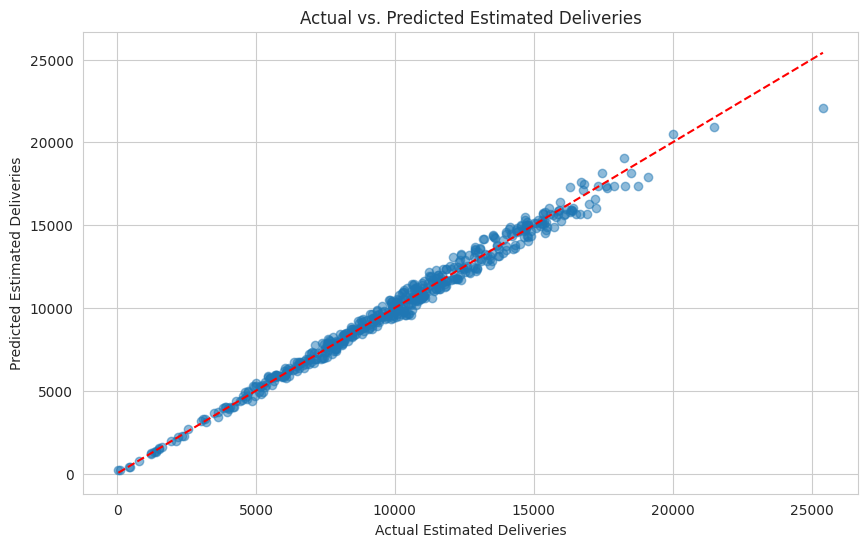

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Estimated Deliveries')
plt.ylabel('Predicted Estimated Deliveries')
plt.title('Actual vs. Predicted Estimated Deliveries')
plt.show()

## 5. Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
                           param_grid=param_grid,
                           cv=3, # Using 3-fold cross-validation
                           n_jobs=-1,
                           verbose=2,
                           scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning complete!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best RMSE found: {np.sqrt(-grid_search.best_score_):.2f}")

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_model.predict(X_test)

mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nEvaluation of Tuned Model on Test Set:")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Hyperparameter tuning complete!
Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE found: 584.41

Evaluation of Tuned Model on Test Set:
Mean Squared Error (MSE): 295938.09
Root Mean Squared Error (RMSE): 544.00
R-squared (R2): 0.98


## 6. Time Series Forecasting


Time Series Forecasting with Prophet:
Mean Squared Error (MSE): 32288992.07
Root Mean Squared Error (RMSE): 5682.34
R-squared (R2): -1.10


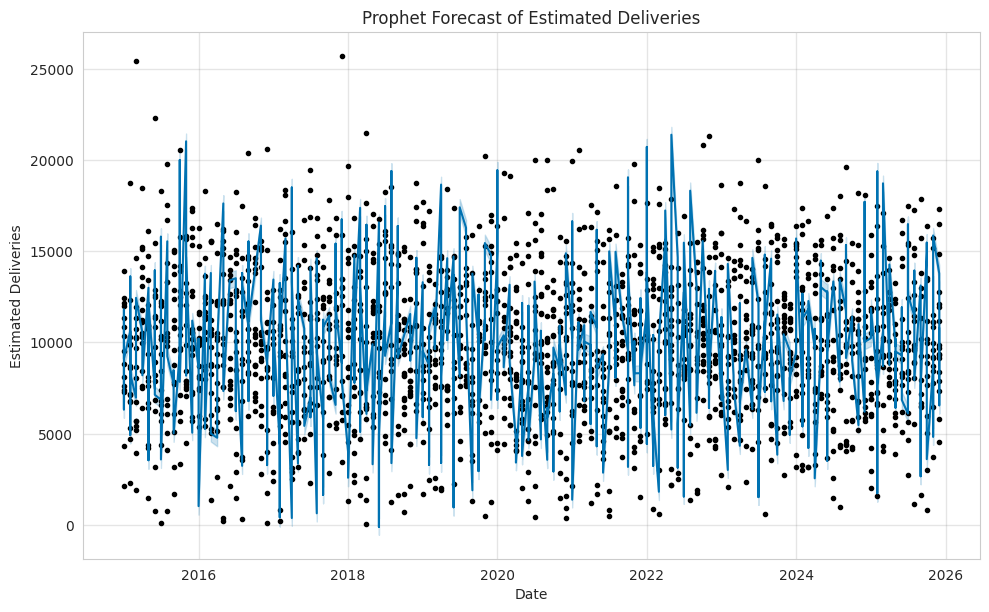

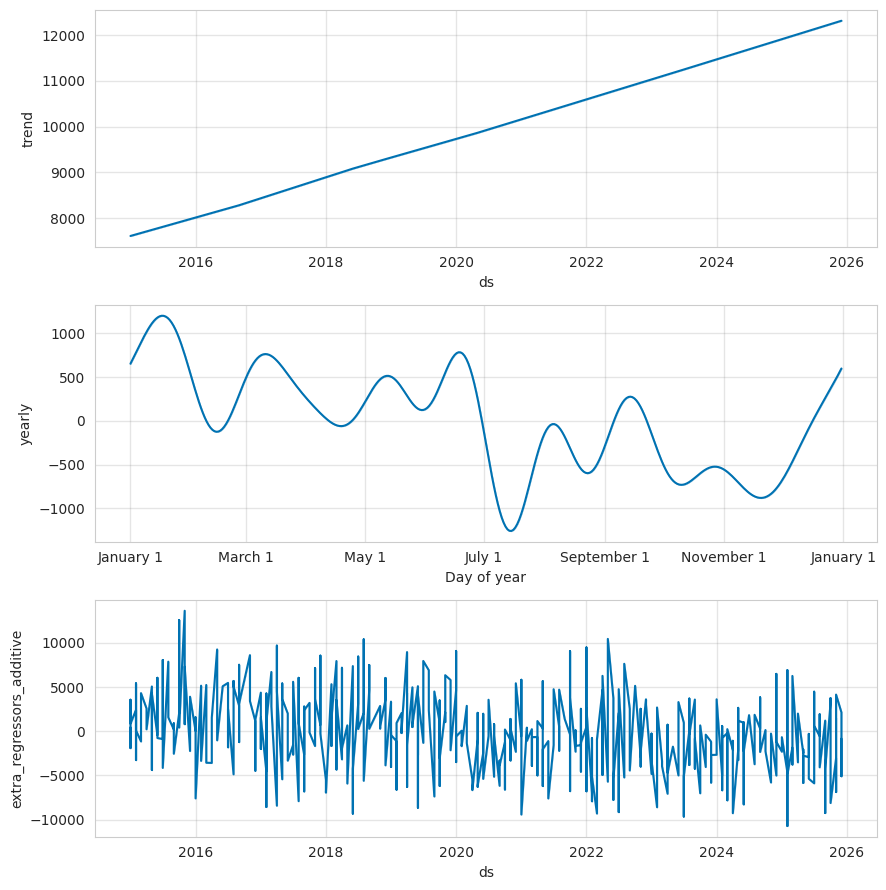

In [18]:
# Install Prophet
!pip install prophet

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for Prophet: Prophet requires columns named 'ds' (datetime) and 'y' (target)
prophet_df = df.reset_index().rename(columns={'Date': 'ds', 'Estimated_Deliveries': 'y'})

# Define exogenous variables to use with Prophet
# Exclude 'Estimated_Deliveries_Lag1' and 'Estimated_Deliveries_Lag2' as Prophet handles its own temporal dependencies
exogenous_cols = [
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Year',
    'Quarter',
    'Month',
    'DayOfWeek',
    'Deliveries_Price_Interaction',
    'Region_Europe',
    'Region_Middle East',
    'Region_North America',
    'Model_Model 3',
    'Model_Model S',
    'Model_Model X',
    'Model_Model Y',
    'Source_Type_Interpolated (Month)',
    'Source_Type_Official (Quarter)'
]

# Ensure all exogenous columns are in prophet_df
# Filter out any columns that might not exist after one-hot encoding if a category was dropped due to drop_first=True
exogenous_cols = [col for col in exogenous_cols if col in prophet_df.columns]

# Chronological split for time series forecasting (e.g., 80% for training, 20% for testing)
train_size = int(len(prophet_df) * 0.8)
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

# Initialize and fit Prophet model
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False, # Data is monthly, so weekly seasonality is not applicable
    daily_seasonality=False
)

# Add exogenous regressors to the model
for col in exogenous_cols:
    m.add_regressor(col)

m.fit(prophet_train)

# Create a DataFrame for future predictions using the test set's dates and exogenous variables
future = prophet_test[['ds'] + exogenous_cols]

# Make predictions
forecast = m.predict(future)

# Evaluate the Prophet model
y_true_prophet = prophet_test['y']
y_pred_prophet = forecast['yhat']

mse_prophet = mean_squared_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mse_prophet)
r2_prophet = r2_score(y_true_prophet, y_pred_prophet)

print(f"\nTime Series Forecasting with Prophet:")
print(f"Mean Squared Error (MSE): {mse_prophet:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_prophet:.2f}")
print(f"R-squared (R2): {r2_prophet:.2f}")

# Plot the forecast
fig1 = m.plot(forecast)
plt.title('Prophet Forecast of Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

# Plot forecast components (trend, seasonality, regressors)
fig2 = m.plot_components(forecast)
plt.show()